# Lab 4: Spatially Aggregated Analysis

In [1]:
import os
import random  # for generating random point
import numpy as np  # for numerical values manipulation (calculation etc.)
import pandas as pd  # for table/spreadsheets manipulation
os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd  # for geospatial data / attribute table & geometry manipulation 
from shapely import wkt  # for geometry data manipulation
import matplotlib.pyplot as plt  # the most basic and important for making plots/figures in Python 
import seaborn as sns  # convenient tools for making statistical plots

import pingouin as pg  # for running hypothesis testing (T-test, ANOVA)
## https://pingouin-stats.org/build/html/index.html  # go to heir documentation website to check the syntax and roadmap


#from shapely.geometry import Point  # for manipulating point data
#from scipy import stats  # for calculating statistical index
#from scipy import special  # 
#from tqdm import tqdm  # for the progress bar
#import mapclassify as mc  # for generating categorisation for numerical data

In [2]:
os.listdir('../resources/')

['hdb_data_2023.csv.xz',
 'GE5230 Reflection Sheet.docx',
 'master-plan-2019-planningarea.zip',
 'BEO_1.md',
 'hdb_data_2013.csv.xz',
 '.ipynb_checkpoints',
 'master-plan-2019-subzone_landuse_area.zip']

## load subzone file

load subzone shapefile

In [29]:
subz = gpd.read_file('../resources/master-plan-2019-subzone_landuse_area.zip')
subz.head()  # get the first 5 rows

,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,drawOrder,...,FMEL_UPD_D,snippet,residentia,commercial,business,outdoor,community_,transporta,other,geometry
0,kml_1,<center><table><tr><th colspan='2' align='cent...,None,None,None,None,-1,0,-1,None,...,20191223152313,None,0.000000,0.000000,0.000000e+00,793768.933514,0.000000,8.019637e+04,9.700715e+05,"POLYGON Z ((33222.981 29588.127 0.000, 33222.5..."
1,kml_2,<center><table><tr><th colspan='2' align='cent...,None,None,None,None,-1,0,-1,None,...,20191223152313,None,224478.035778,4323.531384,0.000000e+00,22815.913511,18844.910472,7.497035e+04,4.713063e+04,"POLYGON Z ((28481.446 30886.220 0.000, 28483.4..."
2,kml_3,<center><table><tr><th colspan='2' align='cent...,None,None,None,None,-1,0,-1,None,...,20191223152313,None,137254.685503,85126.939087,0.000000e+00,85012.915334,3113.920177,1.297321e+05,6.634843e+04,"POLYGON Z ((28087.344 30540.999 0.000, 28087.5..."
3,kml_4,<center><table><tr><th colspan='2' align='cent...,None,None,None,None,-1,0,-1,None,...,20191223152313,None,0.000000,0.000000,3.329913e+07,52906.542628,9979.141886,1.710677e+06,1.565466e+06,"MULTIPOLYGON Z (((14557.697 30447.212 0.000, 1..."
4,kml_5,<center><table><tr><th colspan='2' align='cent...,None,None,None,None,-1,0,-1,None,...,20191223152313,None,13758.277091,12574.427465,0.000000e+00,219189.323708,24648.825853,5.311558e+04,6.544677e+04,"POLYGON Z ((29542.526 31041.199 0.000, 29553.7..."


In [30]:
subz.tail(2)  # get the last 2 rows

,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,drawOrder,...,FMEL_UPD_D,snippet,residentia,commercial,business,outdoor,community_,transporta,other,geometry
330,kml_331,<center><table><tr><th colspan='2' align='cent...,None,None,None,None,-1,0,-1,None,...,20191223152313,None,752228.171195,37253.532097,1.025488e+05,392445.429134,277777.974909,3.612614e+05,4.062924e+04,"POLYGON Z ((29469.703 36372.102 0.000, 29466.1..."
331,kml_332,<center><table><tr><th colspan='2' align='cent...,None,None,None,None,-1,0,-1,None,...,20191223152313,None,0.000000,0.000000,1.990602e+07,90136.769097,98929.908503,1.581408e+06,6.033533e+06,"MULTIPOLYGON Z (((4929.537 32139.355 0.000, 45..."


<Axes: >

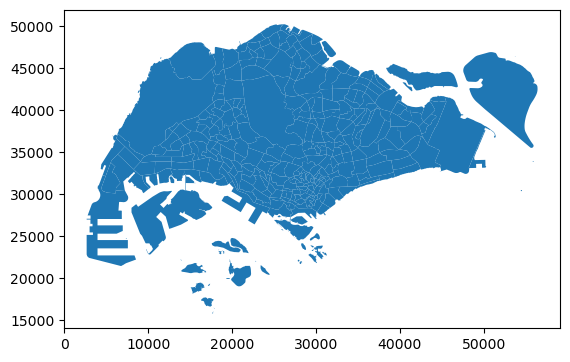

In [31]:
subz.plot()  # show the spatial data

In [32]:
subz.crs  # this is the EPSG:3414 crs

<Projected CRS: PROJCS["SVY21",GEOGCS["GCS_SVY21[WGS84]",DATUM["WG ...>
Name: SVY21
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Transverse Mercator
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [33]:
subz.columns  # show columns, seems like it has too many columns/info

Index(['Name', 'descriptio', 'timestamp', 'begin', 'end', 'altitudeMo',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon',
       'SUBZONE_NO', 'SUBZONE_N', 'SUBZONE_C', 'CA_IND', 'PLN_AREA_N',
       'PLN_AREA_C', 'REGION_N', 'REGION_C', 'INC_CRC', 'FMEL_UPD_D',
       'snippet', 'residentia', 'commercial', 'business', 'outdoor',
       'community_', 'transporta', 'other', 'geometry'],
      dtype='object')

In [35]:
## remove some non-needed columns, and keep only some important one
keep_cols = [
    'SUBZONE_N', 'SUBZONE_C', 
    'PLN_AREA_N', 'PLN_AREA_C', 
    'REGION_N', 'REGION_C', 
    'geometry']

subz = subz[keep_cols].copy()  # overriding the object by assigning the same name, this can be risky but here is ok
subz.head()

,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C,geometry
0,MARINA EAST,MESZ01,MARINA EAST,ME,CENTRAL REGION,CR,"POLYGON Z ((33222.981 29588.127 0.000, 33222.5..."
1,INSTITUTION HILL,RVSZ05,RIVER VALLEY,RV,CENTRAL REGION,CR,"POLYGON Z ((28481.446 30886.220 0.000, 28483.4..."
2,ROBERTSON QUAY,SRSZ01,SINGAPORE RIVER,SR,CENTRAL REGION,CR,"POLYGON Z ((28087.344 30540.999 0.000, 28087.5..."
3,JURONG ISLAND AND BUKOM,WISZ01,WESTERN ISLANDS,WI,WEST REGION,WR,"MULTIPOLYGON Z (((14557.697 30447.212 0.000, 1..."
4,FORT CANNING,MUSZ02,MUSEUM,MU,CENTRAL REGION,CR,"POLYGON Z ((29542.526 31041.199 0.000, 29553.7..."


## load HDB data

In [18]:
hdb = pd.read_csv('../resources/hdb_data_2023.csv.xz', index_col=0)  # first (0) column contain 'index' of the rows
hdb.head()  # show the firs 5 rows (by default, is 5 rows)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,resale_year,resale_month,resale_age,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry
0,2023-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,01 TO 03,44.0,Improved,1979,267000.0,2023,1,44,406 ANG MO KIO AVE 10,1.362005,103.853880,30288.234663,38229.067463,560406,POINT (30288.2346631354 38229.0674628187)
1,2023-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,49.0,Improved,1977,300000.0,2023,1,46,323 ANG MO KIO AVE 3,1.367908,103.847714,29602.047153,38881.891694,560323,POINT (29602.0471531954 38881.8916942235)
2,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,280000.0,2023,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912)
3,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1978,282000.0,2023,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912)
4,2023-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,289800.0,2023,1,37,170 ANG MO KIO AVE 4,1.374001,103.836432,28346.433332,39555.534275,560170,POINT (28346.4333322113 39555.5342750959)


In [17]:
hdb.tail(10)  # show the last 10 rows

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,resale_year,resale_month,resale_age,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry
25750,2023-12,YISHUN,5 ROOM,512C,YISHUN ST 51,10 TO 12,113.0,Improved,2017,750000.0,2023,12,6,512C YISHUN ST 51,1.414958,103.842655,29039.008991,44084.358214,763512,POINT (29039.0089909183 44084.3582140561)
25751,2023-12,YISHUN,5 ROOM,816,YISHUN ST 81,10 TO 12,122.0,Improved,1988,660000.0,2023,12,35,816 YISHUN ST 81,1.411771,103.833368,28005.529905,43731.974231,760816,POINT (28005.5299047483 43731.9742311724)
25752,2023-12,YISHUN,EXECUTIVE,328,YISHUN RING RD,07 TO 09,142.0,Apartment,1988,798000.0,2023,12,35,328 YISHUN RING RD,1.429780,103.843057,29083.732600,45723.276519,760328,POINT (29083.7326004431 45723.2765188329)
25753,2023-12,YISHUN,EXECUTIVE,326,YISHUN RING RD,07 TO 09,146.0,Maisonette,1988,770000.0,2023,12,35,326 YISHUN RING RD,1.429551,103.842440,29015.047402,45698.010440,760326,POINT (29015.0474021444 45698.0104404967)
25754,2023-12,YISHUN,EXECUTIVE,606,YISHUN ST 61,07 TO 09,142.0,Apartment,1987,788888.0,2023,12,36,606 YISHUN ST 61,1.421334,103.836318,28333.820088,44789.428103,760606,POINT (28333.8200883046 44789.4281029589)
25755,2023-12,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,146.0,Maisonette,1987,838000.0,2023,12,36,643 YISHUN ST 61,1.421335,103.837437,28458.318995,44789.537249,760643,POINT (28458.3189945575 44789.5372493081)
25756,2023-12,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,142.0,Apartment,1987,755000.0,2023,12,36,643 YISHUN ST 61,1.421335,103.837437,28458.318995,44789.537249,760643,POINT (28458.3189945575 44789.5372493081)
25757,2023-12,YISHUN,EXECUTIVE,826,YISHUN ST 81,01 TO 03,142.0,Apartment,1988,780000.0,2023,12,35,826 YISHUN ST 81,1.414174,103.832454,27903.805992,43997.703489,760826,POINT (27903.8059915034 43997.7034889162)
25758,2023-12,YISHUN,EXECUTIVE,834,YISHUN ST 81,01 TO 03,142.0,Apartment,1988,785000.0,2023,12,35,834 YISHUN ST 81,1.415088,103.834000,28075.777355,44098.765290,760834,POINT (28075.7773547592 44098.7652900182)
25759,2023-12,YISHUN,MULTI-GENERATION,666,YISHUN AVE 4,01 TO 03,179.0,Multi Generation,1987,975000.0,2023,12,36,666 YISHUN AVE 4,1.418998,103.840568,28806.756365,44531.159086,760666,POINT (28806.7563653113 44531.1590859666)


In [16]:
hdb.columns  # to check what columns is included in the csv/dataframe

Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price',
       'resale_year', 'resale_month', 'resale_age', 'ADDRESS', 'LAT', 'LNG',
       'X', 'Y', 'POSTAL', 'geometry'],
      dtype='object')

In [15]:
hdb['geometry'].apply(wkt.loads)  ## this is what this .apply() do

0        POINT (30288.2346631354 38229.0674628187)
1        POINT (29602.0471531954 38881.8916942235)
2        POINT (29865.9980458226 38695.9702712912)
3        POINT (29865.9980458226 38695.9702712912)
4        POINT (28346.4333322113 39555.5342750959)
                           ...                    
25755    POINT (28458.3189945575 44789.5372493081)
25756    POINT (28458.3189945575 44789.5372493081)
25757    POINT (27903.8059915034 43997.7034889162)
25758    POINT (28075.7773547592 44098.7652900182)
25759    POINT (28806.7563653113 44531.1590859666)
Name: geometry, Length: 25760, dtype: object

<Axes: >

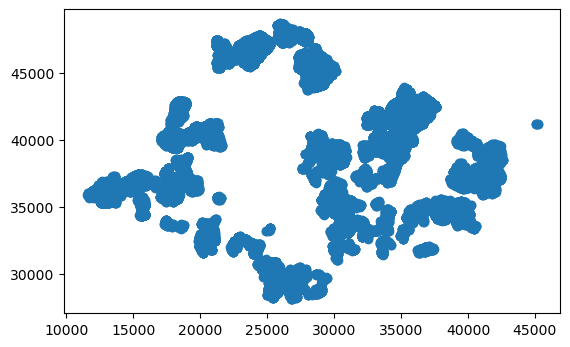

In [13]:
g_hdb = gpd.GeoDataFrame(data=hdb,
                         geometry=hdb['geometry'].apply(wkt.loads), 
                         crs=subz.crs)  # use the same crs as the subzone, make sure they are same before setting it
g_hdb.plot()

In [36]:
## X.sjoin(Y) is the spatial join function, joining the Y to X
## in this case, is to join the polygon info to the point
g_hdb.sjoin(subz)  # testing how it looks, without keeping the test result as a new object

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,Y,POSTAL,geometry,index_right,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C
0,2023-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,01 TO 03,44.0,Improved,1979,267000.0,...,38229.067463,560406,POINT (30288.235 38229.067),162,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER
1,2023-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,49.0,Improved,1977,300000.0,...,38881.891694,560323,POINT (29602.047 38881.892),329,TOWNSVILLE,AMSZ04,ANG MO KIO,AM,NORTH-EAST REGION,NER
2,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,280000.0,...,38695.970271,560314,POINT (29865.998 38695.970),329,TOWNSVILLE,AMSZ04,ANG MO KIO,AM,NORTH-EAST REGION,NER
3,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1978,282000.0,...,38695.970271,560314,POINT (29865.998 38695.970),329,TOWNSVILLE,AMSZ04,ANG MO KIO,AM,NORTH-EAST REGION,NER
4,2023-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,289800.0,...,39555.534275,560170,POINT (28346.433 39555.534),171,KEBUN BAHRU,AMSZ06,ANG MO KIO,AM,NORTH-EAST REGION,NER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25755,2023-12,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,146.0,Maisonette,1987,838000.0,...,44789.537249,760643,POINT (28458.319 44789.537),221,YISHUN SOUTH,YSSZ04,YISHUN,YS,NORTH REGION,NR
25756,2023-12,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,142.0,Apartment,1987,755000.0,...,44789.537249,760643,POINT (28458.319 44789.537),221,YISHUN SOUTH,YSSZ04,YISHUN,YS,NORTH REGION,NR
25757,2023-12,YISHUN,EXECUTIVE,826,YISHUN ST 81,01 TO 03,142.0,Apartment,1988,780000.0,...,43997.703489,760826,POINT (27903.806 43997.703),221,YISHUN SOUTH,YSSZ04,YISHUN,YS,NORTH REGION,NR
25758,2023-12,YISHUN,EXECUTIVE,834,YISHUN ST 81,01 TO 03,142.0,Apartment,1988,785000.0,...,44098.765290,760834,POINT (28075.777 44098.765),221,YISHUN SOUTH,YSSZ04,YISHUN,YS,NORTH REGION,NR


In [37]:
g_hdb2 = g_hdb.sjoin(subz)  # save the  spatial join result as a new geopandas object
# assign it to a new name, which is safer (not overriding)
g_hdb2.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,Y,POSTAL,geometry,index_right,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C
0,2023-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,01 TO 03,44.0,Improved,1979,267000.0,...,38229.067463,560406,POINT (30288.235 38229.067),162,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER
1,2023-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,49.0,Improved,1977,300000.0,...,38881.891694,560323,POINT (29602.047 38881.892),329,TOWNSVILLE,AMSZ04,ANG MO KIO,AM,NORTH-EAST REGION,NER
2,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,280000.0,...,38695.970271,560314,POINT (29865.998 38695.970),329,TOWNSVILLE,AMSZ04,ANG MO KIO,AM,NORTH-EAST REGION,NER
3,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1978,282000.0,...,38695.970271,560314,POINT (29865.998 38695.970),329,TOWNSVILLE,AMSZ04,ANG MO KIO,AM,NORTH-EAST REGION,NER
4,2023-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,289800.0,...,39555.534275,560170,POINT (28346.433 39555.534),171,KEBUN BAHRU,AMSZ06,ANG MO KIO,AM,NORTH-EAST REGION,NER


## try individual transaction analysis

check the resale prices between regions


<Axes: xlabel='resale_price', ylabel='Count'>

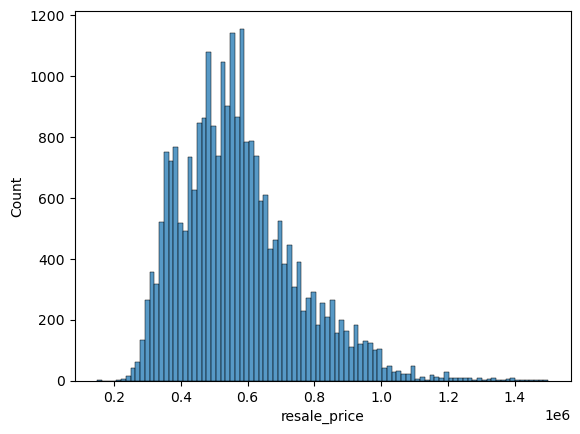

In [39]:
sns.histplot(g_hdb2['resale_price'])

<Axes: xlabel='REGION_C', ylabel='resale_price'>

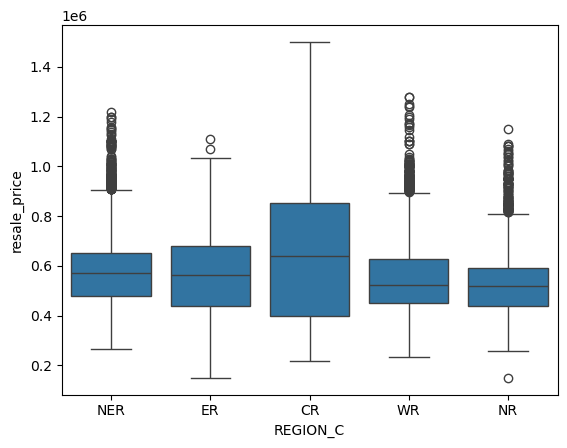

In [46]:
sns.boxplot(x='REGION_C', y='resale_price', data=g_hdb2)

<Axes: xlabel='REGION_C', ylabel='resale_price'>

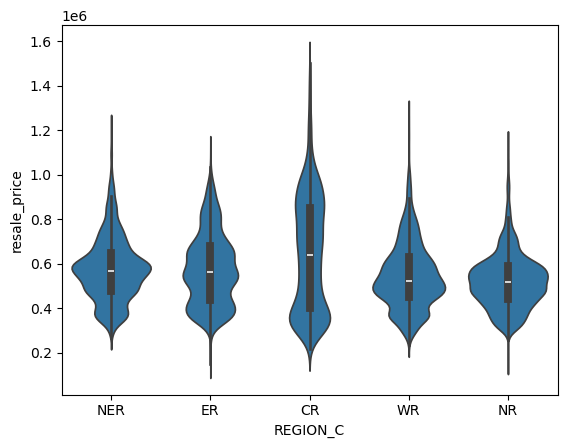

In [47]:
sns.violinplot(x='REGION_C', y='resale_price', data=g_hdb2)

<Axes: xlabel='floor_area_sqm', ylabel='resale_price'>

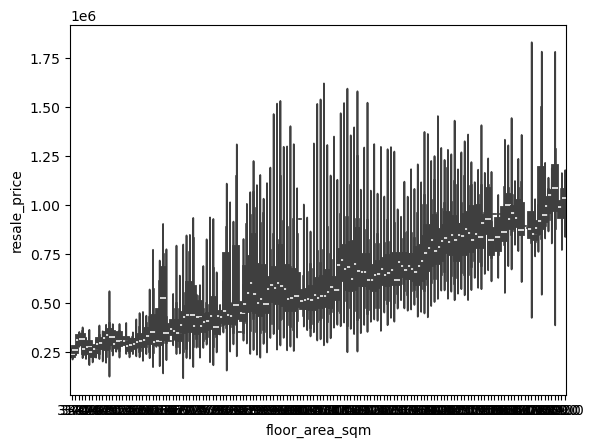

In [48]:
sns.violinplot(x='floor_area_sqm', y='resale_price', data=g_hdb2)

<Axes: xlabel='flat_type', ylabel='resale_price'>

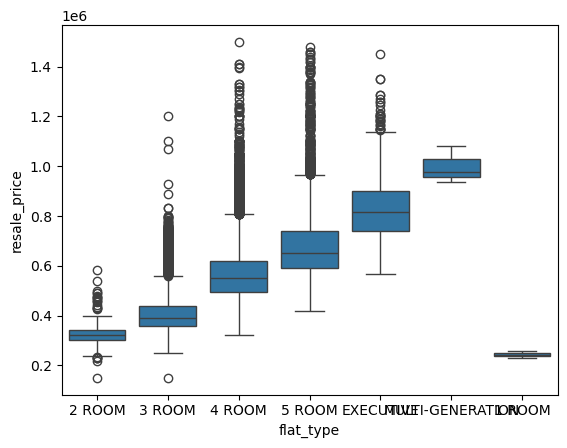

In [49]:
sns.boxplot(x='flat_type', y='resale_price', data=g_hdb2)

<Axes: xlabel='flat_type', ylabel='resale_price'>

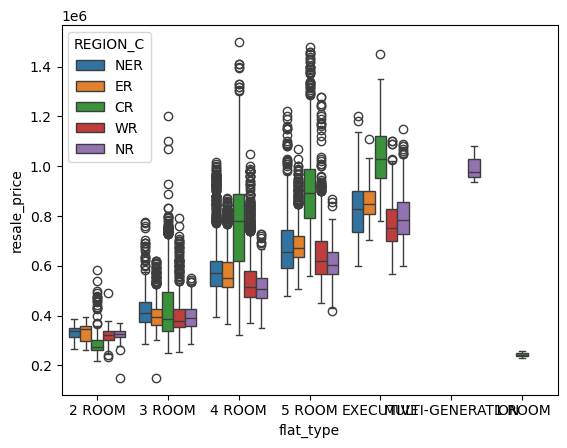

In [50]:
sns.boxplot(x='flat_type', y='resale_price', hue='REGION_C', data=g_hdb2)

let's rearange things so that it is more intuitive

<Axes: xlabel='flat_type', ylabel='resale_price'>

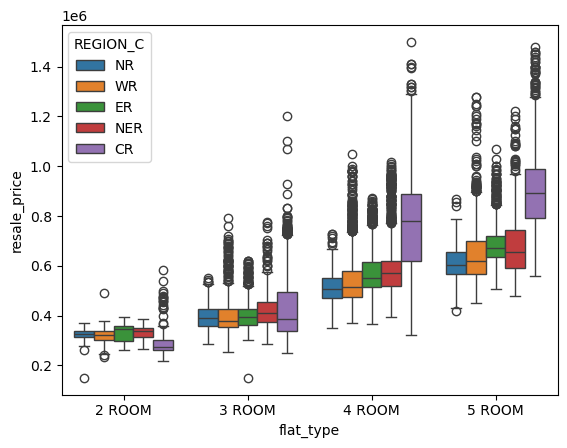

In [52]:
sns.boxplot(x='flat_type', y='resale_price', hue='REGION_C', data=g_hdb2,
            order=['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM'], 
            hue_order=['NR', 'WR', 'ER', 'NER', 'CR'],
           )

In [53]:
sns.color_palette('muted')

[(0.2823529411764706, 0.47058823529411764, 0.8156862745098039),
 (0.9333333333333333, 0.5215686274509804, 0.2901960784313726),
 (0.41568627450980394, 0.8, 0.39215686274509803),
 (0.8392156862745098, 0.37254901960784315, 0.37254901960784315),
 (0.5843137254901961, 0.4235294117647059, 0.7058823529411765),
 (0.5490196078431373, 0.3803921568627451, 0.23529411764705882),
 (0.8627450980392157, 0.49411764705882355, 0.7529411764705882),
 (0.4745098039215686, 0.4745098039215686, 0.4745098039215686),
 (0.8352941176470589, 0.7333333333333333, 0.403921568627451),
 (0.5098039215686274, 0.7764705882352941, 0.8862745098039215)]

<Axes: xlabel='flat_type', ylabel='resale_price'>

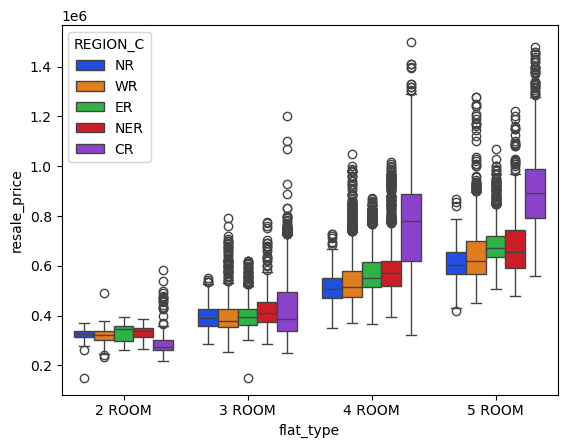

In [57]:
sns.boxplot(x='flat_type', y='resale_price', hue='REGION_C', data=g_hdb2,
            order=['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM'], 
            hue_order=['NR', 'WR', 'ER', 'NER', 'CR'],
            palette=sns.color_palette('bright')[:5]
           )

# an interesting point here:
- CR is lower than other regions for 2 room, about the same for 3 room, and higher than other zones for 4 and 5 rooms
- for 2/3 rooms, the outliers are visibly higher

**is it because of the numbers are less in CR?, let's check**

In [58]:
g_hdb2.groupby('REGION_C')[['resale_price']].count()

,resale_price
REGION_C,
CR,4487
ER,3568
NER,6916
NR,4889
WR,5900


In [61]:
g_hdb2.groupby(['flat_type', 'REGION_C'])[['resale_price']].count()

resale_price
flat_type        REGION_C              
1 ROOM           CR                   6
2 ROOM           CR                 128
                 ER                  34
                 NER                201
                 NR                 197
                 WR                 129
3 ROOM           CR                1817
                 ER                 981
                 NER               1386
                 NR                 872
                 WR                1300
4 ROOM           CR                1744
                 ER                1394
                 NER               3294
                 NR                2355
                 WR                2571
5 ROOM           CR                 676
                 ER                 840
                 NER               1717
                 NR                1161
                 WR                1451
EXECUTIVE        CR                 116
                 ER                 319
                 NER                318
                 NR                 301
                 WR                 449
MULTI-GENERATION NR                   3

in terms of # transaction, CR doesn't seem to be different from others
note that the word 'seem'<--means visually speaking

### remark 1
so, different flat type may have different price pattern between regions

traditionally we may want to use 2-ways anova, here let's use what we cover in the class: one-way anova

run one-way ANOVA separately for different flat type, between REGION

In [65]:
g_hdb2['flat_type']=='1 ROOM', len(g_hdb2)

(0        False
 1        False
 2        False
 3        False
 4        False
          ...  
 25755    False
 25756    False
 25757    False
 25758    False
 25759    False
 Name: flat_type, Length: 25760, dtype: bool,
 25760)

In [66]:
g_hdb2[g_hdb2['flat_type']=='1 ROOM']

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,Y,POSTAL,geometry,index_right,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C
4750,2023-03,BUKIT MERAH,1 ROOM,7,TELOK BLANGAH CRES,01 TO 03,31.0,Improved,1975,237000.0,...,28980.23008,090007,POINT (26449.194 28980.230),17,TELOK BLANGAH WAY,BMSZ14,BUKIT MERAH,BM,CENTRAL REGION,CR
7020,2023-04,BUKIT MERAH,1 ROOM,7,TELOK BLANGAH CRES,04 TO 06,31.0,Improved,1975,240000.0,...,28980.23008,090007,POINT (26449.194 28980.230),17,TELOK BLANGAH WAY,BMSZ14,BUKIT MERAH,BM,CENTRAL REGION,CR
9229,2023-05,BUKIT MERAH,1 ROOM,7,TELOK BLANGAH CRES,01 TO 03,31.0,Improved,1975,251000.0,...,28980.23008,090007,POINT (26449.194 28980.230),17,TELOK BLANGAH WAY,BMSZ14,BUKIT MERAH,BM,CENTRAL REGION,CR
19805,2023-10,BUKIT MERAH,1 ROOM,7,TELOK BLANGAH CRES,01 TO 03,31.0,Improved,1975,243000.0,...,28980.23008,090007,POINT (26449.194 28980.230),17,TELOK BLANGAH WAY,BMSZ14,BUKIT MERAH,BM,CENTRAL REGION,CR
19806,2023-10,BUKIT MERAH,1 ROOM,7,TELOK BLANGAH CRES,04 TO 06,31.0,Improved,1975,229000.0,...,28980.23008,090007,POINT (26449.194 28980.230),17,TELOK BLANGAH WAY,BMSZ14,BUKIT MERAH,BM,CENTRAL REGION,CR
21994,2023-11,BUKIT MERAH,1 ROOM,7,TELOK BLANGAH CRES,10 TO 12,31.0,Improved,1975,258000.0,...,28980.23008,090007,POINT (26449.194 28980.230),17,TELOK BLANGAH WAY,BMSZ14,BUKIT MERAH,BM,CENTRAL REGION,CR


In [79]:
ftypes = ['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM']

## declare the empty list for storing results
a_res_all = []  # for storing anova result
ph_res_all = []  # for storing post-hoc result
for ft in ftypes:
    tmp = g_hdb2[g_hdb2['flat_type']==ft]
    #print(ft, len(tmp))
    # run anova
    a_res = pg.anova(data=tmp, dv='resale_price', between='REGION_C',)
    a_res['flat_type'] = ft
    #print(a_res)
    a_res_all.append(a_res) # store anova result
    # run post-hoc 
    ph_res = pg.pairwise_tukey(data=tmp, dv='resale_price', between='REGION_C').round(3)
    #ph_res['p-tukey'] = ph_res['p-tukey'].round(4)
    ph_res['mean(A)'] = ph_res['mean(A)'].round(1)
    ph_res['mean(B)'] = ph_res['mean(B)'].round(1)
    ph_res['diff'] = ph_res['diff'].round(1)
    ph_res['flat_type'] = ft
    #print(ph_res)
    ph_res_all.append(ph_res)  # store post-hoc result
    
a_res_all = pd.concat(a_res_all)  # combine the dataframes in the list into one dataframe
#ph_res_all = pd.concat(ph_res_all)
a_res_all#, ph_res_all

,Source,ddof1,ddof2,F,p-unc,np2,flat_type
0,REGION_C,4,684,13.981083,5.702313e-11,0.075581,2 ROOM
0,REGION_C,4,6351,58.785339,8.328396e-49,0.035702,3 ROOM
0,REGION_C,4,11353,1644.679298,0.000000e+00,0.366876,4 ROOM
0,REGION_C,4,5840,865.388524,0.000000e+00,0.372148,5 ROOM


In [82]:
for ph_res in ph_res_all:
    tmp = ph_res[ph_res['p-tukey']<=.05]  # filter to get significant row only
    print(tmp)

     A    B   mean(A)   mean(B)     diff        se      T  p-tukey  hedges  \
0   CR   ER  300024.4  331823.5 -31799.1  7635.973 -4.164    0.000  -0.477   
1   CR  NER  300024.4  332277.5 -32253.1  4475.548 -7.207    0.000  -0.654   
2   CR   NR  300024.4  323819.1 -23794.7  4493.191 -5.296    0.000  -0.490   
3   CR   WR  300024.4  319457.4 -19432.9  4937.624 -3.936    0.001  -0.344   
8  NER   WR  332277.5  319457.4  12820.1  4464.938  2.871    0.034   0.444   

  flat_type  
0    2 ROOM  
1    2 ROOM  
2    2 ROOM  
3    2 ROOM  
8    2 ROOM  
     A    B   mean(A)   mean(B)     diff        se       T  p-tukey  hedges  \
0   CR   ER  433591.6  401849.1  31742.5  3442.264   9.221      0.0   0.286   
1   CR  NER  433591.6  419594.1  13997.5  3098.501   4.518      0.0   0.131   
2   CR   NR  433591.6  393648.0  39943.6  3579.249  11.160      0.0   0.359   
3   CR   WR  433591.6  393328.1  40263.6  3156.105  12.757      0.0   0.363   
4   ER  NER  401849.1  419594.1 -17745.0  3625.060  

## summary

- for 2 room, CR is significantly lower than all others; NER > WR
- for 3 room, CR is significantly higher than all others (this is not visible); NER > (ER, NR, WR)
- for 4 and 5 rooms:
    - CR > all
    - ER > most of them
    - NER > NR & WR
    - NR < WR
- ER and NER, some times one is significantly higher than another, which does not always stand for other flat type
    - this means that, for different flat types, the relationship (> or <) may change between regions

## try to see how the different flat type in each region

In [95]:
regs = ['CR', 'ER', 'NR', 'NER', 'WR']

a_res_all2 = []
for reg in regs:
    tmp = g_hdb2[g_hdb2['REGION_C']==reg]
    #print(tmp.head())
    a_res = pg.anova(data=tmp, dv='resale_price', between='flat_type',)
    a_res['REGION_C'] = reg
    a_res_all2.append(a_res)
    print(a_res)
    break

# note the ddof1: the flat type contains 1 room, executive, and multi-gen, which we don't want 

      Source  ddof1  ddof2            F  p-unc       np2 REGION_C
0  flat_type      5   4481  1487.958521    0.0  0.624102       CR


In [115]:
keep_ft = ['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM']
g_hdb3 = g_hdb2[[ft in keep_ft for ft in g_hdb2['flat_type']]].copy()
len(g_hdb3)

24248

In [99]:
regs = ['CR', 'ER', 'NR', 'NER', 'WR']

a_res_all2 = []
ph_res_all2 = []
for reg in regs:
    tmp = g_hdb3[g_hdb3['REGION_C']==reg]
    #print(tmp.head())
    a_res = pg.anova(data=tmp, dv='resale_price', between='flat_type',)
    a_res['REGION_C'] = reg
    a_res_all2.append(a_res)
    #print(a_res)  # check the ddof1 and ddof2
    ph_res = pg.pairwise_tukey(data=tmp, dv='resale_price', between='flat_type').round(3)
    #ph_res['p-tukey'] = ph_res['p-tukey'].round(4)
    ph_res['mean(A)'] = ph_res['mean(A)'].round(1)
    ph_res['mean(B)'] = ph_res['mean(B)'].round(1)
    ph_res['diff'] = ph_res['diff'].round(1)
    ph_res['flat_type'] = reg
    #print(ph_res)
    ph_res_all2.append(ph_res)
    #break

a_res_all2 = pd.concat(a_res_all2)  # combine the dataframes in the list into one dataframe
a_res_all2

,Source,ddof1,ddof2,F,p-unc,np2,REGION_C
0,flat_type,3,4361,2207.724091,0.0,0.602974,CR
0,flat_type,3,3245,2015.361828,0.0,0.650740,ER
0,flat_type,3,4581,3166.579463,0.0,0.674662,NR
0,flat_type,3,6594,2543.364540,0.0,0.536420,NER
0,flat_type,3,5447,1798.161356,0.0,0.497578,WR


In [101]:
for ph in ph_res_all2:
    ph2 = ph[ph['p-tukey']<=.05]
    print(ph)

        A       B   mean(A)   mean(B)      diff         se       T  p-tukey  \
0  2 ROOM  3 ROOM  300024.4  433591.6 -133567.2  14600.533  -9.148      0.0   
1  2 ROOM  4 ROOM  300024.4  763596.3 -463571.9  14620.629 -31.707      0.0   
2  2 ROOM  5 ROOM  300024.4  912139.3 -612114.8  15390.086 -39.773      0.0   
3  3 ROOM  4 ROOM  433591.6  763596.3 -330004.7   5352.130 -61.659      0.0   
4  3 ROOM  5 ROOM  433591.6  912139.3 -478547.6   7192.861 -66.531      0.0   
5  4 ROOM  5 ROOM  763596.3  912139.3 -148542.9   7233.566 -20.535      0.0   

   hedges flat_type  
0  -1.039        CR  
1  -2.637        CR  
2  -3.638        CR  
3  -2.092        CR  
4  -3.267        CR  
5  -0.821        CR  
        A       B   mean(A)   mean(B)      diff         se       T  p-tukey  \
0  2 ROOM  3 ROOM  331823.5  401849.1  -70025.6  14298.016  -4.898      0.0   
1  2 ROOM  4 ROOM  331823.5  573620.1 -241796.6  14226.890 -16.996      0.0   
2  2 ROOM  5 ROOM  331823.5  690956.7 -359133.2  14338.

all regions indicated that 2 room < 3 room < 4 room < 5 room

## test run 2-ways anova

In [88]:
pg.anova(data=g_hdb3, dv='resale_price', between=['REGION_C', 'flat_type'], detailed=True)

,Source,SS,DF,MS,F,p-unc,np2
0,REGION_C,8.450466e+13,4.0,2.112617e+13,2033.595336,0.0,0.251353
1,flat_type,3.162643e+14,3.0,1.054214e+14,10147.820819,0.0,0.556844
2,REGION_C * flat_type,3.577816e+13,12.0,2.981513e+12,286.999119,0.0,0.124458
3,Residual,2.516945e+14,24228.0,1.038858e+10,NaN,NaN,NaN


the two main effects (regions and flat type) are significant, as well as the interaction effect


## try aggregated analysis (aggregate by subzone) and mixed anova

mixed means contains both between and within data
- between: mutually exclusive groups, subjects in one 'group' cannot appear in another 'group'
- within: every subject must have one value in the all 'groups'

individual transaction data is mutually exclusive, because all transaction happens in only one location, has one flat type, has one and only one value in all columns.... so there is no 'within' group properties in it

to demonstrate mixed anova, we need to aggregate the transaction into some spatial units, then the spatial units can contains multiple transactions that falls in different groups, e.g., different flat types appear in the same subzone. Then, we can calculate the median/mean price for each type in the same subzone. 


In [102]:
g_hdb3.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,Y,POSTAL,geometry,index_right,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C
0,2023-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,01 TO 03,44.0,Improved,1979,267000.0,...,38229.067463,560406,POINT (30288.235 38229.067),162,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER
1,2023-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,49.0,Improved,1977,300000.0,...,38881.891694,560323,POINT (29602.047 38881.892),329,TOWNSVILLE,AMSZ04,ANG MO KIO,AM,NORTH-EAST REGION,NER
2,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,280000.0,...,38695.970271,560314,POINT (29865.998 38695.970),329,TOWNSVILLE,AMSZ04,ANG MO KIO,AM,NORTH-EAST REGION,NER
3,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1978,282000.0,...,38695.970271,560314,POINT (29865.998 38695.970),329,TOWNSVILLE,AMSZ04,ANG MO KIO,AM,NORTH-EAST REGION,NER
4,2023-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,289800.0,...,39555.534275,560170,POINT (28346.433 39555.534),171,KEBUN BAHRU,AMSZ06,ANG MO KIO,AM,NORTH-EAST REGION,NER


In [104]:
g_hdb3.groupby('SUBZONE_N')[['resale_price']].mean()

,resale_price
SUBZONE_N,
ADMIRALTY,491582.265060
ALEXANDRA HILL,598892.294085
ALJUNIED,579236.190476
ANAK BUKIT,921494.909091
ANCHORVALE,574497.724138
...,...
YISHUN SOUTH,523087.597674
YISHUN WEST,415818.701754
YUHUA EAST,456596.260274


In [129]:
g_hdb4 = g_hdb3.groupby(['REGION_C', 'SUBZONE_N', 'flat_type'])[['resale_price']].median().reset_index()

g_hdb4  ## long table

,REGION_C,SUBZONE_N,flat_type,resale_price
0,CR,ALEXANDRA HILL,2 ROOM,290000.0
1,CR,ALEXANDRA HILL,3 ROOM,328000.0
2,CR,ALEXANDRA HILL,4 ROOM,700000.0
3,CR,ALEXANDRA HILL,5 ROOM,836944.0
4,CR,ALJUNIED,2 ROOM,297500.0
...,...,...,...,...
482,WR,YUHUA WEST,5 ROOM,600000.0
483,WR,YUNNAN,2 ROOM,280000.0
484,WR,YUNNAN,3 ROOM,365000.0
485,WR,YUNNAN,4 ROOM,460000.0


In [131]:
g_hdb4b = g_hdb4.pivot(index=['REGION_C', 'SUBZONE_N'], columns='flat_type', values='resale_price').reset_index()
## all 'within group' data can be arranged into wide table, like this, 
## where each row represent a subject, and multiple columns containing the same variable (resale price) for different groups (flat type) 
g_hdb4b  # wide table

flat_type,REGION_C,SUBZONE_N,2 ROOM,3 ROOM,4 ROOM,5 ROOM
0,CR,ALEXANDRA HILL,290000.0,328000.0,700000.0,836944.0
1,CR,ALJUNIED,297500.0,380000.0,650000.0,852000.0
2,CR,ANAK BUKIT,NaN,NaN,805000.0,1050000.0
3,CR,BALESTIER,NaN,345000.0,704500.0,790000.0
4,CR,BENCOOLEN,328000.0,380000.0,788000.0,NaN
...,...,...,...,...,...,...
146,WR,WENYA,NaN,NaN,449000.0,518000.0
147,WR,YEW TEE,NaN,NaN,478444.0,540000.0
148,WR,YUHUA EAST,NaN,366500.0,465000.0,628000.0
149,WR,YUHUA WEST,302500.0,375250.0,482500.0,600000.0


In [132]:
for col in ftypes:
    #print(col)
    nan_count_col = g_hdb4b[col].isna().sum()
    print(col, nan_count_col)
# perhaps we should remove 2 room, 87 missing value is more than 50% of the subzones

2 ROOM 87
3 ROOM 15
4 ROOM 4
5 ROOM 11


In [133]:
87/151  # 57.6%

0.5761589403973509

In [134]:
g_hdb4c = g_hdb4b[['REGION_C', 'SUBZONE_N', '3 ROOM', '4 ROOM', '5 ROOM']]
g_hdb4c = g_hdb4c.dropna()
len(g_hdb4c)

125

In [135]:
g_hdb4c  # the wide table

flat_type,REGION_C,SUBZONE_N,3 ROOM,4 ROOM,5 ROOM
0,CR,ALEXANDRA HILL,328000.0,700000.0,836944.0
1,CR,ALJUNIED,380000.0,650000.0,852000.0
3,CR,BALESTIER,345000.0,704500.0,790000.0
5,CR,BENDEMEER,399500.0,839000.0,1023000.0
6,CR,BISHAN EAST,493000.0,635000.0,890000.0
...,...,...,...,...,...
144,WR,TECK WHYE,378000.0,460000.0,575000.0
145,WR,TOH GUAN,381000.0,530888.0,708000.0
148,WR,YUHUA EAST,366500.0,465000.0,628000.0
149,WR,YUHUA WEST,375250.0,482500.0,600000.0


let's make some plots

0 CR 45
flat_type
3 ROOM    408000.0
4 ROOM    713444.0
5 ROOM    861500.0
dtype: float64
1 ER 8
flat_type
3 ROOM    389500.0
4 ROOM    563000.0
5 ROOM    688000.0
dtype: float64
2 NER 26
flat_type
3 ROOM    407500.0
4 ROOM    571500.0
5 ROOM    715000.0
dtype: float64
3 NR 16
flat_type
3 ROOM    411250.0
4 ROOM    498000.0
5 ROOM    595000.0
dtype: float64
4 WR 30
flat_type
3 ROOM    380500.0
4 ROOM    500000.0
5 ROOM    632500.0
dtype: float64


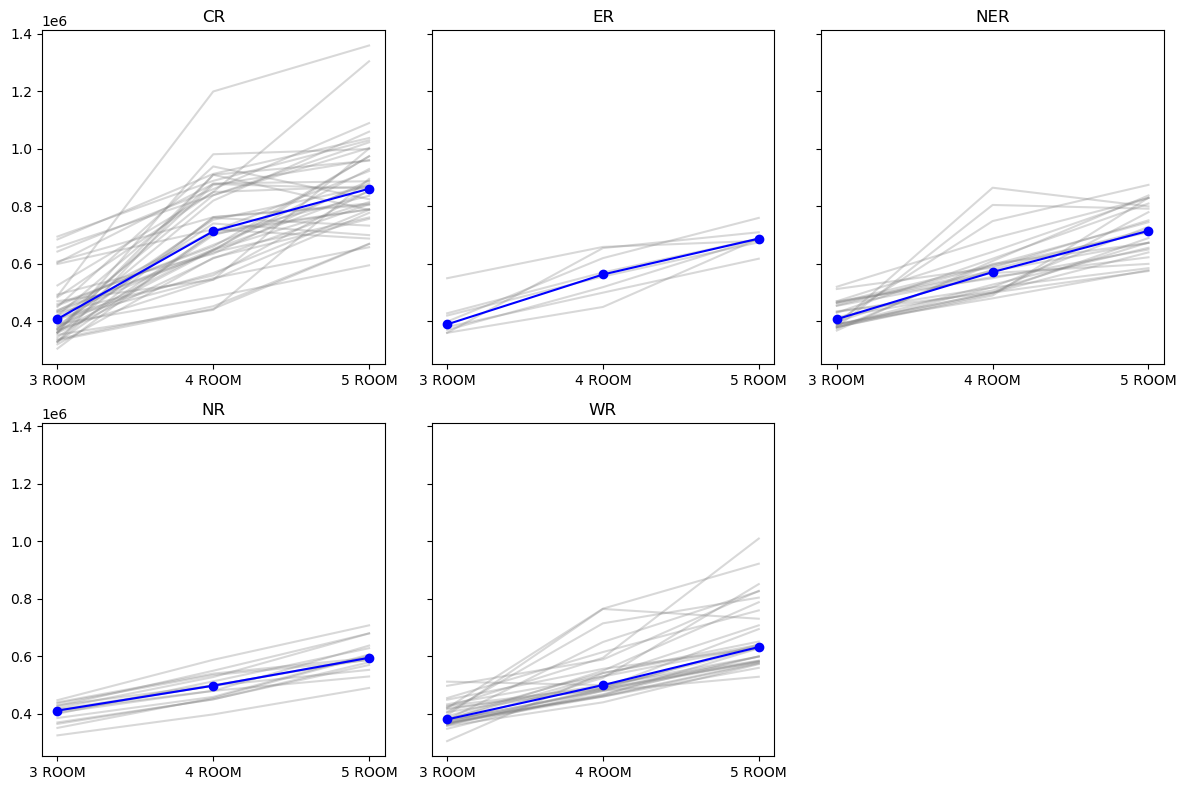

In [163]:
ftypes2 = ['3 ROOM', '4 ROOM', '5 ROOM']

fig, axg = plt.subplots(2, 3, figsize=(12, 8), sharex=False, sharey=True)
axs = axg.flatten()

for i, reg in enumerate(g_hdb4c['REGION_C'].unique()):
    ax = axs[i]
    tmp = g_hdb4c[g_hdb4c['REGION_C']==reg]
    #print(tmp)
    print(i, reg, len(tmp))
    for j, row in tmp.iterrows():
        #print(row)
        vs = [row[ft] for ft in ftypes2]
        #print(vs)
        ax.plot(list(range(3)), vs, c='grey', alpha=.3)
        #break
    tmp2 = tmp[ftypes2].median()
    print(tmp2)
    ax.plot(list(range(3)), tmp2, c='blue', marker='o')
    ax.set_title(reg)
    #break
for ax in axs:
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(ftypes2)

axs[-1].axis('off')

plt.tight_layout()


In [139]:
g_hdb4c_long = g_hdb4c.melt(id_vars=['REGION_C', 'SUBZONE_N'])  # convert it back to long table
g_hdb4c_long = g_hdb4c_long.rename(columns={'value': 'resale_price'})
g_hdb4c_long

,REGION_C,SUBZONE_N,flat_type,resale_price
0,CR,ALEXANDRA HILL,3 ROOM,328000.0
1,CR,ALJUNIED,3 ROOM,380000.0
2,CR,BALESTIER,3 ROOM,345000.0
3,CR,BENDEMEER,3 ROOM,399500.0
4,CR,BISHAN EAST,3 ROOM,493000.0
...,...,...,...,...
370,WR,TECK WHYE,5 ROOM,575000.0
371,WR,TOH GUAN,5 ROOM,708000.0
372,WR,YUHUA EAST,5 ROOM,628000.0
373,WR,YUHUA WEST,5 ROOM,600000.0


In [164]:
pg.mixed_anova(data=g_hdb4c_long, dv='resale_price', within='flat_type', subject='SUBZONE_N', between='REGION_C',)

,Source,SS,DF1,DF2,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,REGION_C,1.797383e+12,4,120,4.493457e+11,21.694839,1.731484e-13,NaN,0.419671,NaN,NaN,NaN,NaN
1,flat_type,6.975618e+12,2,240,3.487809e+12,542.605936,8.935336e-90,5.985883e-68,0.818897,0.854165,False,0.829267,0.00001
2,Interaction,5.828804e+11,8,240,7.286005e+10,11.334994,1.319473e-13,NaN,0.274223,NaN,NaN,NaN,NaN


In [166]:
mph = pg.pairwise_tests(data=g_hdb4c_long, dv='resale_price', between='REGION_C', within='flat_type', subject='SUBZONE_N',
                          parametric=True, marginal=True, alpha=0.05, alternative='two-sided', 
                          padjust='none', effsize='hedges', correction='auto', nan_policy='listwise', 
                          return_desc=False, interaction=True, within_first=True)
mph

,Contrast,flat_type,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,flat_type,-,3 ROOM,4 ROOM,True,True,-15.895738,124.000000,two-sided,1.051045e-31,2.918e+28,-1.672786
1,flat_type,-,3 ROOM,5 ROOM,True,True,-24.938102,124.000000,two-sided,3.791171e-50,4.708e+46,-2.711672
2,flat_type,-,4 ROOM,5 ROOM,True,True,-15.066078,124.000000,two-sided,8.536083e-30,3.844e+26,-0.896488
3,REGION_C,-,CR,ER,False,True,5.419548,25.782608,two-sided,1.144687e-05,6789.44,1.170566
4,REGION_C,-,CR,NER,False,True,5.188191,68.273477,two-sided,2.068298e-06,7059.712,1.077828
5,REGION_C,-,CR,NR,False,True,9.119660,58.838961,two-sided,7.401146e-13,6.553e+09,1.786777
6,REGION_C,-,CR,WR,False,True,6.801916,72.644025,two-sided,2.468995e-09,3.526e+06,1.448330
7,REGION_C,-,ER,NER,False,True,-1.059594,14.684420,two-sided,3.064481e-01,0.556,-0.367638
8,REGION_C,-,ER,NR,False,True,2.833456,13.029460,two-sided,1.407065e-02,5.23,1.221558
9,REGION_C,-,ER,WR,False,True,0.840834,16.865600,two-sided,4.122040e-01,0.474,0.257270


In [168]:
mph[mph['p-unc']>.05]

,Contrast,flat_type,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
7,REGION_C,-,ER,NER,False,True,-1.059594,14.684420,two-sided,0.306448,0.556,-0.367638
9,REGION_C,-,ER,WR,False,True,0.840834,16.865600,two-sided,0.412204,0.474,0.257270
13,flat_type * REGION_C,3 ROOM,CR,ER,False,True,0.961031,14.978158,two-sided,0.351795,0.502,0.257568
14,flat_type * REGION_C,3 ROOM,CR,NER,False,True,0.664554,64.722707,two-sided,0.508697,0.304,0.133911
15,flat_type * REGION_C,3 ROOM,CR,NR,False,True,1.795779,58.902214,two-sided,0.077659,1.058,0.343840
17,flat_type * REGION_C,3 ROOM,ER,NER,False,True,-0.595660,9.258105,two-sided,0.565678,0.422,-0.282948
18,flat_type * REGION_C,3 ROOM,ER,NR,False,True,0.247917,9.189726,two-sided,0.809650,0.397,0.125315
19,flat_type * REGION_C,3 ROOM,ER,WR,False,True,0.506569,8.889738,two-sided,0.624782,0.402,0.243667
20,flat_type * REGION_C,3 ROOM,NER,NR,False,True,1.638280,37.615644,two-sided,0.109703,0.885,0.481220
22,flat_type * REGION_C,3 ROOM,NR,WR,False,True,0.513398,37.376573,two-sided,0.610695,0.338,0.145456


In [169]:
mph[mph['p-unc']<=.05]

,Contrast,flat_type,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,flat_type,-,3 ROOM,4 ROOM,True,True,-15.895738,124.000000,two-sided,1.051045e-31,2.918e+28,-1.672786
1,flat_type,-,3 ROOM,5 ROOM,True,True,-24.938102,124.000000,two-sided,3.791171e-50,4.708e+46,-2.711672
2,flat_type,-,4 ROOM,5 ROOM,True,True,-15.066078,124.000000,two-sided,8.536083e-30,3.844e+26,-0.896488
3,REGION_C,-,CR,ER,False,True,5.419548,25.782608,two-sided,1.144687e-05,6789.44,1.170566
4,REGION_C,-,CR,NER,False,True,5.188191,68.273477,two-sided,2.068298e-06,7059.712,1.077828
5,REGION_C,-,CR,NR,False,True,9.119660,58.838961,two-sided,7.401146e-13,6.553e+09,1.786777
6,REGION_C,-,CR,WR,False,True,6.801916,72.644025,two-sided,2.468995e-09,3.526e+06,1.448330
8,REGION_C,-,ER,NR,False,True,2.833456,13.029460,two-sided,1.407065e-02,5.23,1.221558
10,REGION_C,-,NER,NR,False,True,4.879311,38.881241,two-sided,1.843305e-05,979.224,1.407740
11,REGION_C,-,NER,WR,False,True,2.236484,53.921843,two-sided,2.947815e-02,2.071,0.583123


3 parts: 
- the within group result: Contrast==flat_type
    - 3 room < 4 room < 5 room, which are expected
- the between group result: Contrast==REGION_C
    - CR > all other regions
    - ER > NR
    - NER > NR and WR
    - NR > WR
- the interaction: Contrast==flat_type * REGION_C
    - this examine if there is differences on "regional-relationship or regional-differences" between flat types
    - 4 rooms and 5 rooms are same, but 3 rooms have less significant result

In [170]:
mph2 = pg.pairwise_tests(data=g_hdb4c_long, dv='resale_price', between='REGION_C', within='flat_type', subject='SUBZONE_N',
                          parametric=True, marginal=True, alpha=0.05, alternative='two-sided', 
                          padjust='none', effsize='hedges', correction='auto', nan_policy='listwise', 
                          return_desc=False, interaction=True, within_first=False)
mph2

,Contrast,REGION_C,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,REGION_C,-,CR,ER,False,True,5.419548,25.782608,two-sided,1.144687e-05,6789.44,1.170566
1,REGION_C,-,CR,NER,False,True,5.188191,68.273477,two-sided,2.068298e-06,7059.712,1.077828
2,REGION_C,-,CR,NR,False,True,9.119660,58.838961,two-sided,7.401146e-13,6.553e+09,1.786777
3,REGION_C,-,CR,WR,False,True,6.801916,72.644025,two-sided,2.468995e-09,3.526e+06,1.448330
4,REGION_C,-,ER,NER,False,True,-1.059594,14.684420,two-sided,3.064481e-01,0.556,-0.367638
5,REGION_C,-,ER,NR,False,True,2.833456,13.029460,two-sided,1.407065e-02,5.23,1.221558
6,REGION_C,-,ER,WR,False,True,0.840834,16.865600,two-sided,4.122040e-01,0.474,0.257270
7,REGION_C,-,NER,NR,False,True,4.879311,38.881241,two-sided,1.843305e-05,979.224,1.407740
8,REGION_C,-,NER,WR,False,True,2.236484,53.921843,two-sided,2.947815e-02,2.071,0.583123
9,REGION_C,-,NR,WR,False,True,-2.256625,43.280138,two-sided,2.913533e-02,2.201,-0.592426


In [171]:
mph2[mph2['p-unc']>.05]

,Contrast,REGION_C,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
4,REGION_C,-,ER,NER,False,True,-1.059594,14.68442,two-sided,0.306448,0.556,-0.367638
6,REGION_C,-,ER,WR,False,True,0.840834,16.86560,two-sided,0.412204,0.474,0.257270


the interaction effect: 
are there any differences on the "flat types relationships" between regions---they were all significant and same accross regions